In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

In [13]:
x , y = load_diabetes(return_X_y=True)

In [15]:
x.shape

(442, 10)

In [104]:
cr = pd.DataFrame(x)

<Axes: >

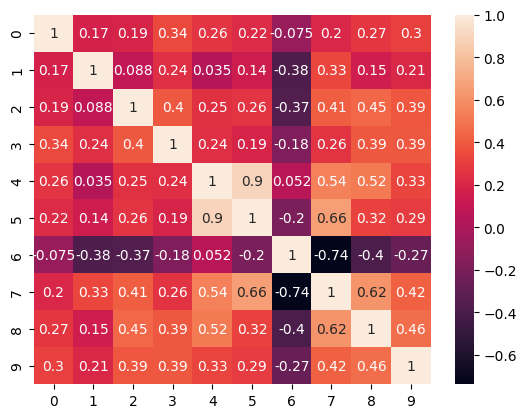

In [107]:
import seaborn as sns
sns.heatmap(cr.iloc[:,0:11].corr(),annot=True)

In [17]:
pd.DataFrame(y)

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [19]:
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size=0.2, random_state=42)

In [57]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(353, 10)
(353,)
(89, 10)
(89,)


In [32]:
reg = LinearRegression()

In [34]:
reg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = reg.predict(x_test)


In [95]:
y_pred

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

In [41]:
r2_score(y_test,y_pred)

0.4526027629719197

In [42]:
reg.coef_

array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [43]:
reg.intercept_

np.float64(151.34560453985995)

Making own regrission class

In [91]:
class meralr:
    def __init__(self):
        self.coef__ = None
        self.intercept__ = None
    def fit(self,x_train , y_train):
        x_train = np.insert(x_train,0,1,axis=1)
        
        #calculate the coeff
        betas = np.linalg.inv(np.dot(x_train.T,x_train)).dot(x_train.T).dot(y_train)

        self.coef__ = betas[0]
        self.intercept__ = betas[1:]
        print(self.coef__)
        print(self.intercept__)

    def predict(self, x_test):
        return np.dot(x_test,self.coef__) + self.intercept__
        

       
        
      
        




In [93]:
leg = meralr()
leg.fit(x_train, y_train)


151.34560453985998
[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


In [94]:
leg.predict(x_test)

array([[  44.76617988, -248.72067778,  541.48951464,  345.28246934,
        -912.56781468,  537.01045929,  166.32385065,  280.51039657,
         741.10734861,   47.88066298],
       [  51.91317335, -248.72067778,  548.01439943,  351.01413332,
        -935.26645615,  515.54113889,  163.53785216,  269.34075167,
         732.79108131,   45.37310428],
       [  47.51502352, -234.2941491 ,  541.81575888,  345.8035297 ,
        -915.89972535,  525.44641033,  171.89584765,  274.92557412,
         748.98628069,   45.99999395],
       [  52.46294207, -248.72067778,  550.29810911,  359.70020956,
        -923.18827995,  523.59805824,  151.83665848,  296.70638166,
         751.12880941,   57.91089778],
       [  39.81826133, -234.2941491 ,  539.36892708,  347.36671079,
        -925.68721296,  526.10992134,  162.42345276,  280.51039657,
         735.42061108,   47.2537733 ],
       [  39.2684926 , -248.72067778,  538.7164386 ,  343.71928825,
        -916.5244586 ,  532.3184886 ,  174.12464644,  274